In [22]:
import os
from pathlib import Path

DATASET_PATH = Path("/kaggle/input/datasets/gillesokhin/nutrition5k-dataset")

print("Dataset exists:", DATASET_PATH.exists())
print("\nContents:")
for item in DATASET_PATH.iterdir():
    print(item)

Dataset exists: True

Contents:
/kaggle/input/datasets/gillesokhin/nutrition5k-dataset/dish_nutrition_values.csv
/kaggle/input/datasets/gillesokhin/nutrition5k-dataset/ingredients_metadata.csv
/kaggle/input/datasets/gillesokhin/nutrition5k-dataset/imagery
/kaggle/input/datasets/gillesokhin/nutrition5k-dataset/dish_ingredients.csv


In [23]:
print("\nDataset structure:\n")

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(str(DATASET_PATH), "").count(os.sep)

    if level <= 2:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        for file in files[:10]:
            print(f"{indent}    {file}")


Dataset structure:

nutrition5k-dataset/
    dish_nutrition_values.csv
    ingredients_metadata.csv
    dish_ingredients.csv
    imagery/
        realsense_overhead/
        side_angles/


In [24]:
import pandas as pd
from pathlib import Path

DATASET_PATH = Path("/kaggle/input/datasets/gillesokhin/nutrition5k-dataset")

nutrition_file = DATASET_PATH / "dish_nutrition_values.csv"

nutrition_df = pd.read_csv(nutrition_file)

print("Shape:", nutrition_df.shape)
print("\nColumns:")
print(nutrition_df.columns.tolist())

print("\nFirst 5 rows:")
display(nutrition_df.head())

Shape: (4768, 6)

Columns:
['dish_id', 'calories', 'mass', 'fat', 'carb', 'protein']

First 5 rows:


,dish_id,calories,mass,fat,carb,protein
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000


In [25]:
print("\nData types:")
print(nutrition_df.dtypes)

print("\nMissing values:")
print(nutrition_df.isnull().sum())


Data types:
dish_id      object
calories    float64
mass        float64
fat         float64
carb        float64
protein     float64
dtype: object

Missing values:
dish_id     0
calories    0
mass        0
fat         0
carb        0
protein     0
dtype: int64


In [26]:
import os
import pandas as pd
from pathlib import Path

# Paths
DATASET_PATH = Path("/kaggle/input/datasets/gillesokhin/nutrition5k-dataset")
IMAGE_PATH = DATASET_PATH / "imagery" / "realsense_overhead"

# Load nutrition labels
nutrition_df = pd.read_csv(
    DATASET_PATH / "dish_nutrition_values.csv"
)

# Create image paths
nutrition_df["image_path"] = nutrition_df["dish_id"].apply(
    lambda x: str(IMAGE_PATH / x / "rgb.png")
)

# Check whether each image exists
nutrition_df["image_exists"] = nutrition_df["image_path"].apply(
    os.path.exists
)

print("Total dishes:", len(nutrition_df))
print("Images found:", nutrition_df["image_exists"].sum())
print("Images missing:", (~nutrition_df["image_exists"]).sum())

Total dishes: 4768
Images found: 3244
Images missing: 1524


In [27]:
# Keep only dishes with valid RGB images
dataset_df = nutrition_df[nutrition_df["image_exists"]].copy()

# Keep only the columns we need
dataset_df = dataset_df[
    ["dish_id", "image_path", "calories", "fat", "carb", "protein", "mass"]
].reset_index(drop=True)

print("Final dataset size:", len(dataset_df))

display(dataset_df.head())

Final dataset size: 3244


,dish_id,image_path,calories,fat,carb,protein,mass
0,dish_1561662216,/kaggle/input/datasets/gillesokhin/nutrition5k...,300.794281,12.387489,28.218290,18.633970,193.0
1,dish_1561662054,/kaggle/input/datasets/gillesokhin/nutrition5k...,419.438782,23.838249,26.351543,25.910593,292.0
2,dish_1562008979,/kaggle/input/datasets/gillesokhin/nutrition5k...,382.936646,22.224644,10.173570,35.345387,290.0
3,dish_1560455030,/kaggle/input/datasets/gillesokhin/nutrition5k...,20.590000,0.148000,4.625000,0.956000,103.0
4,dish_1558372433,/kaggle/input/datasets/gillesokhin/nutrition5k...,74.360001,0.286000,0.429000,20.020000,143.0


In [28]:
print("Nutrition statistics:")
display(
    dataset_df[
        ["calories", "fat", "carb", "protein", "mass"]
    ].describe()
)

Nutrition statistics:


,calories,fat,carb,protein,mass
count,3244.000000,3244.000000,3244.000000,3244.000000,3244.000000
mean,255.774014,12.764934,19.408974,18.082945,215.351110
std,219.642807,13.517096,21.637006,20.066933,161.622151
min,0.000000,0.000000,0.000000,0.000000,1.000000
25%,81.119995,1.903610,6.232687,2.168250,93.000000
50%,210.316384,8.919987,15.366159,11.641067,177.500000
75%,375.460839,19.086206,27.535250,28.107748,305.250000
max,3943.325195,106.343002,844.568604,147.491821,3051.000000


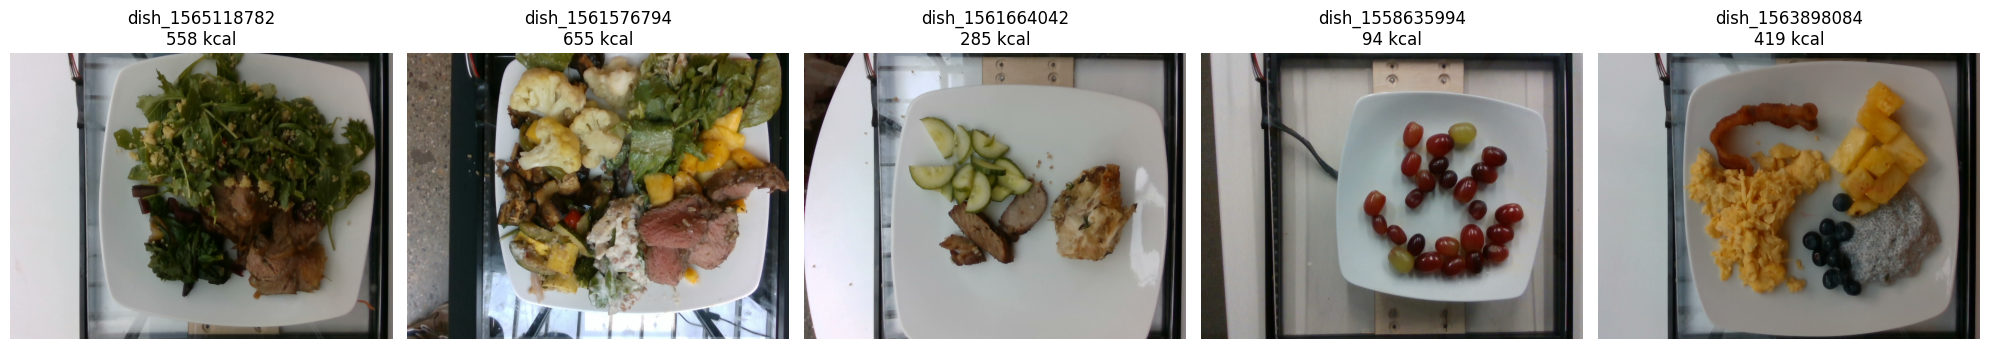

In [29]:
from PIL import Image
import matplotlib.pyplot as plt

# Display 5 sample images
sample_df = dataset_df.sample(5, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    
    ax.imshow(image)
    ax.set_title(
        f"{row['dish_id']}\n"
        f"{row['calories']:.0f} kcal"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [30]:
image_sizes = []

for path in dataset_df["image_path"].sample(
    min(100, len(dataset_df)),
    random_state=42
):
    with Image.open(path) as img:
        image_sizes.append(img.size)

print("Unique image dimensions:")
print(set(image_sizes))

Unique image dimensions:
{(640, 480)}


In [31]:
from sklearn.model_selection import train_test_split

# Target columns
target_columns = ["calories", "fat", "carb", "protein"]

# First split: 80% train, 20% temporary
train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.20,
    random_state=42
)

# Second split: 10% validation, 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Training samples: 2595
Validation samples: 324
Test samples: 325
Total: 3244


In [32]:
print("TRAIN")
display(train_df[target_columns].describe())

print("\nVALIDATION")
display(val_df[target_columns].describe())

print("\nTEST")
display(test_df[target_columns].describe())

TRAIN


,calories,fat,carb,protein
count,2595.000000,2595.000000,2595.000000,2595.000000
mean,254.123811,12.698971,19.395473,17.814100
std,221.348239,13.489569,22.754859,19.735297
min,0.000000,0.000000,0.000000,0.000000
25%,81.119995,1.989065,6.156064,2.099696
50%,207.569000,8.823172,15.411839,11.434039
75%,372.247299,18.947188,27.530902,27.669120
max,3943.325195,90.776642,844.568604,147.491821



VALIDATION


,calories,fat,carb,protein
count,324.000000,324.000000,324.000000,324.000000
mean,248.907359,12.114344,19.662751,17.522940
std,209.937071,13.744577,16.239306,20.038358
min,2.300000,0.032000,0.000000,0.112000
25%,74.230000,0.952750,6.477500,2.116631
50%,197.315415,7.657336,15.177675,8.796500
75%,380.057434,18.495599,27.944208,29.573000
max,1324.084961,106.343002,74.708344,100.636749



TEST


,calories,fat,carb,protein
count,325.000000,325.000000,325.000000,325.000000
mean,275.795776,13.940215,19.263783,20.787851
std,214.953310,13.482042,16.657786,22.444562
min,1.150000,0.017000,0.000000,0.085000
25%,96.681755,3.165525,6.608891,2.880000
50%,244.421005,11.235999,15.138750,14.000000
75%,390.254456,20.378201,27.178827,29.707369
max,1158.989990,73.225998,98.616127,133.227585


In [33]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

# --------------------------------------------------
# Device
# --------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# --------------------------------------------------
# Image transformations
# --------------------------------------------------

# ImageNet normalization because we will use
# ImageNet-pretrained ResNet50

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


# --------------------------------------------------
# Dataset
# --------------------------------------------------

class NutritionDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        self.targets = [
            "calories",
            "fat",
            "carb",
            "protein"
        ]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Load RGB image
        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Nutrient targets
        target = torch.tensor(
            row[self.targets].values.astype(np.float32),
            dtype=torch.float32
        )

        return image, target


# --------------------------------------------------
# Create datasets
# --------------------------------------------------

train_dataset = NutritionDataset(
    train_df,
    transform=train_transform
)

val_dataset = NutritionDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = NutritionDataset(
    test_df,
    transform=val_test_transform
)


# --------------------------------------------------
# DataLoaders
# --------------------------------------------------

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("\nDatasets:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nBatches:")
print("Train:", len(train_loader))
print("Validation:", len(val_loader))
print("Test:", len(test_loader))

Device: cuda
GPU: Tesla T4

Datasets:
Train: 2595
Validation: 324
Test: 325

Batches:
Train: 163
Validation: 21
Test: 21


In [34]:
images, targets = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Target batch shape:", targets.shape)

print("\nTarget example:")
print(targets[0])

print("\nTarget names:")
print(["calories", "fat", "carb", "protein"])

Image batch shape: torch.Size([16, 3, 224, 224])
Target batch shape: torch.Size([16, 4])

Target example:
tensor([418.9524,  27.3019,   7.5076,  33.9575])

Target names:
['calories', 'fat', 'carb', 'protein']


In [35]:
import numpy as np

target_columns = ["calories", "fat", "carb", "protein"]

# Calculate statistics ONLY from training data
target_mean = train_df[target_columns].mean().values.astype(np.float32)
target_std = train_df[target_columns].std().values.astype(np.float32)

print("Training target means:")
for name, value in zip(target_columns, target_mean):
    print(f"{name:12s}: {value:.4f}")

print("\nTraining target standard deviations:")
for name, value in zip(target_columns, target_std):
    print(f"{name:12s}: {value:.4f}")

Training target means:
calories    : 254.1238
fat         : 12.6990
carb        : 19.3955
protein     : 17.8141

Training target standard deviations:
calories    : 221.3482
fat         : 13.4896
carb        : 22.7549
protein     : 19.7353


In [36]:
class NutritionDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        target_mean=None,
        target_std=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        self.targets = [
            "calories",
            "fat",
            "carb",
            "protein"
        ]

        self.target_mean = target_mean
        self.target_std = target_std

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Load RGB image
        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Nutrient targets
        target = row[self.targets].values.astype(np.float32)

        # Standardize targets
        if self.target_mean is not None:
            target = (
                target - self.target_mean
            ) / self.target_std

        target = torch.tensor(
            target,
            dtype=torch.float32
        )

        return image, target

In [37]:
train_dataset = NutritionDataset(
    train_df,
    transform=train_transform,
    target_mean=target_mean,
    target_std=target_std
)

val_dataset = NutritionDataset(
    val_df,
    transform=val_test_transform,
    target_mean=target_mean,
    target_std=target_std
)

test_dataset = NutritionDataset(
    test_df,
    transform=val_test_transform,
    target_mean=target_mean,
    target_std=target_std
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Datasets recreated successfully.")

Datasets recreated successfully.


In [38]:
images, targets = next(iter(train_loader))

print("Image shape:", images.shape)
print("Target shape:", targets.shape)

print("\nStandardized target example:")
print(targets[0])

Image shape: torch.Size([16, 3, 224, 224])
Target shape: torch.Size([16, 4])

Standardized target example:
tensor([-0.1246,  0.0287, -0.4970,  0.2067])


In [39]:
import torch
import torch.nn as nn
from torchvision import models

# --------------------------------------------------
# ResNet50 model
# --------------------------------------------------

model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V2
)

# Number of features entering the final layer
num_features = model.fc.in_features

# Replace ImageNet classification head
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(128, 4)
)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [40]:
# Test forward pass
images, targets = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    predictions = model(images)

print("Input shape:", images.shape)
print("Output shape:", predictions.shape)
print("Output example:", predictions[0])

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 4])
Output example: tensor([ 0.0330,  0.0186, -0.0581, -0.0785], device='cuda:0')


In [41]:
import torch.optim as optim

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Learning-rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss:", criterion)
print("Optimizer:", optimizer)
print("Initial learning rate:", optimizer.param_groups[0]["lr"])

Loss: MSELoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
Initial learning rate: 0.0001


In [42]:
import copy
import time
import numpy as np

# --------------------------------------------------
# Training configuration
# --------------------------------------------------

NUM_EPOCHS = 25
PATIENCE = 5

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "learning_rate": []
}


# --------------------------------------------------
# Training loop
# --------------------------------------------------

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # ==========================
    # Training
    # ==========================

    model.train()

    running_train_loss = 0.0

    for images, targets in train_loader:

        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, targets)

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    train_loss = (
        running_train_loss /
        len(train_loader.dataset)
    )


    # ==========================
    # Validation
    # ==========================

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, targets in val_loader:

            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, targets)

            running_val_loss += loss.item() * images.size(0)

    val_loss = (
        running_val_loss /
        len(val_loader.dataset)
    )


    # ==========================
    # Learning-rate scheduler
    # ==========================

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]


    # ==========================
    # Save history
    # ==========================

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["learning_rate"].append(current_lr)


    # ==========================
    # Save best model
    # ==========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

        print(
            f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"✓ Best"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"LR: {current_lr:.2e}"
        )


    elapsed = time.time() - start_time

    print(f"   Time: {elapsed:.1f}s")


    # ==========================
    # Early stopping
    # ==========================

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping triggered at epoch "
            f"{epoch+1}."
        )

        break


# --------------------------------------------------
# Restore best model
# --------------------------------------------------

model.load_state_dict(best_model_state)

print("\nTraining complete.")
print("Best validation loss:", best_val_loss)

Epoch 01/25 | Train Loss: 0.6726 | Val Loss: 0.3247 | LR: 1.00e-04 | ✓ Best
   Time: 36.3s
Epoch 02/25 | Train Loss: 0.4533 | Val Loss: 0.3481 | LR: 1.00e-04
   Time: 35.0s
Epoch 03/25 | Train Loss: 0.3842 | Val Loss: 0.2746 | LR: 1.00e-04 | ✓ Best
   Time: 34.3s
Epoch 04/25 | Train Loss: 0.3245 | Val Loss: 0.2912 | LR: 1.00e-04
   Time: 35.5s
Epoch 05/25 | Train Loss: 0.2938 | Val Loss: 0.4305 | LR: 1.00e-04
   Time: 34.5s
Epoch 06/25 | Train Loss: 0.2614 | Val Loss: 0.5868 | LR: 5.00e-05
   Time: 34.8s
Epoch 07/25 | Train Loss: 0.1749 | Val Loss: 9.1879 | LR: 5.00e-05
   Time: 34.9s
Epoch 08/25 | Train Loss: 0.1139 | Val Loss: 7.5403 | LR: 5.00e-05
   Time: 34.9s

Early stopping triggered at epoch 8.

Training complete.
Best validation loss: 0.27459792388074195


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import torch

# --------------------------------------------------
# Evaluate best model on test set
# --------------------------------------------------

model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(device)
        targets = targets.to(device)

        outputs = model(images)

        all_predictions.append(
            outputs.cpu().numpy()
        )

        all_targets.append(
            targets.cpu().numpy()
        )


# Combine batches
predictions_std = np.concatenate(
    all_predictions,
    axis=0
)

targets_std = np.concatenate(
    all_targets,
    axis=0
)

# --------------------------------------------------
# Convert back to original nutritional units
# --------------------------------------------------

predictions = (
    predictions_std * target_std
) + target_mean

targets = (
    targets_std * target_std
) + target_mean


# --------------------------------------------------
# Calculate metrics
# --------------------------------------------------

metrics = []

for i, nutrient in enumerate(target_columns):

    mae = mean_absolute_error(
        targets[:, i],
        predictions[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            targets[:, i],
            predictions[:, i]
        )
    )

    r2 = r2_score(
        targets[:, i],
        predictions[:, i]
    )

    metrics.append({
        "Nutrient": nutrient,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


metrics_df = pd.DataFrame(metrics)

print("Test-set performance:")
display(metrics_df)

Test-set performance:


,Nutrient,MAE,RMSE,R2
0,calories,70.977135,107.731695,0.748037
1,fat,5.054172,7.821516,0.662395
2,carb,7.179393,10.005042,0.638139
3,protein,6.974548,11.195033,0.750445


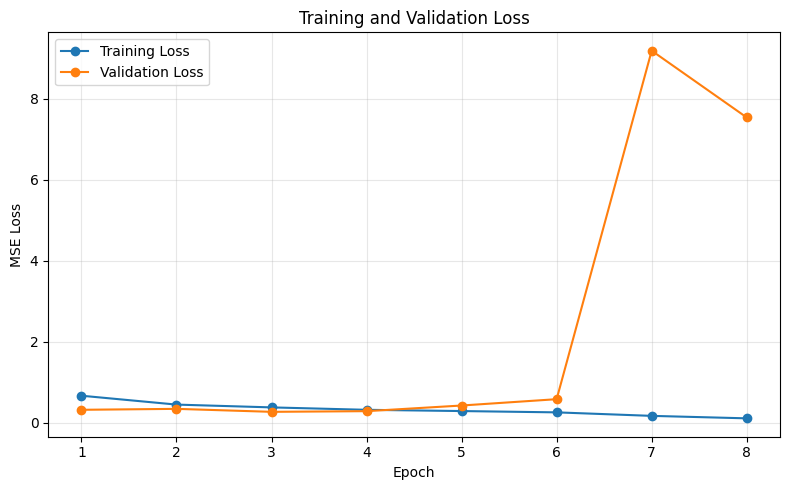

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(history["train_loss"]) + 1),
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, len(history["val_loss"]) + 1),
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

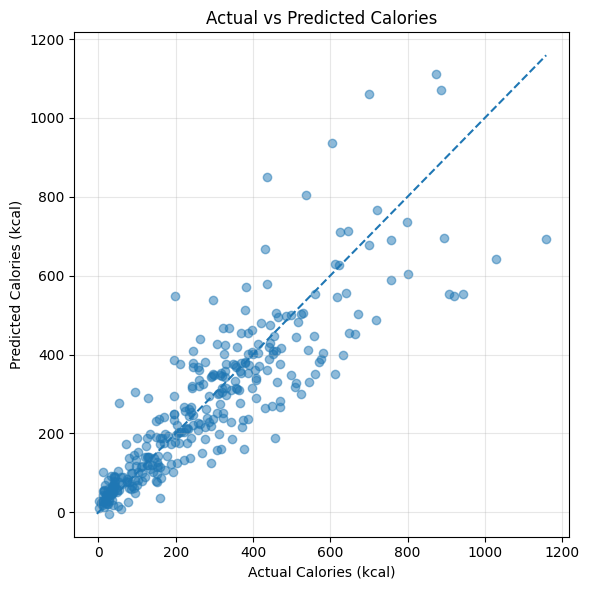

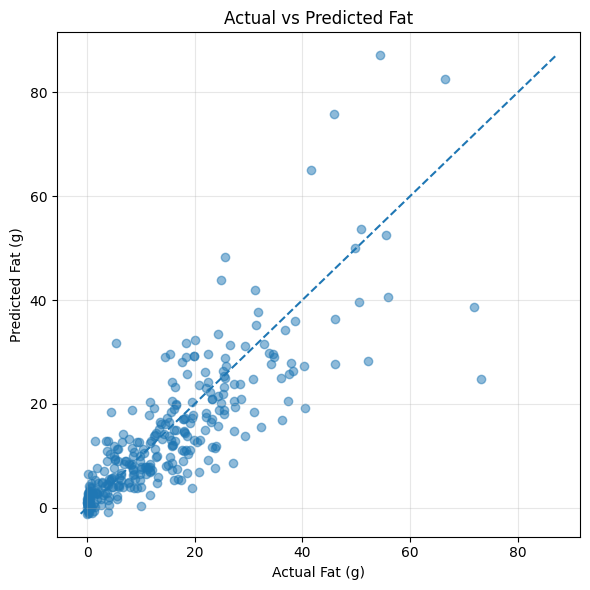

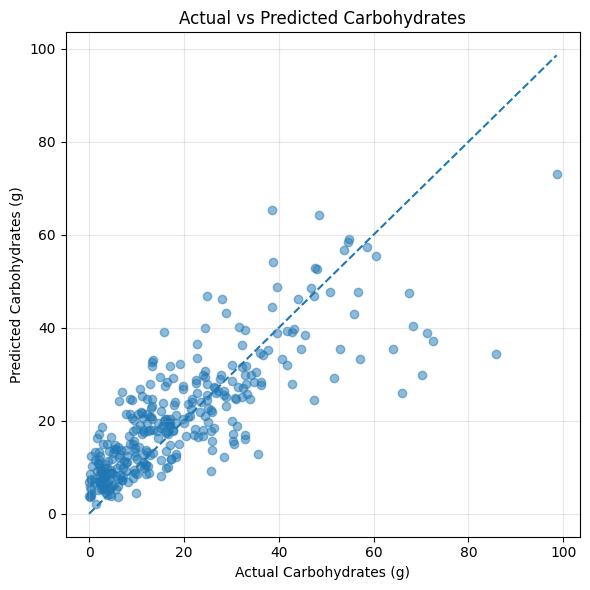

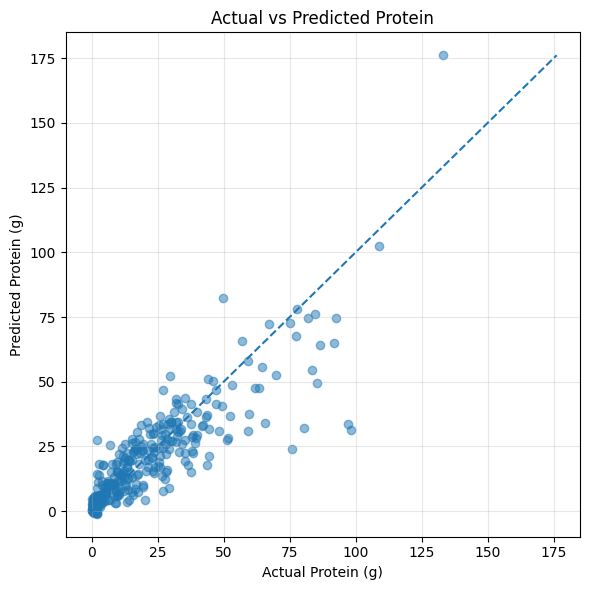

In [47]:
nutrient_names = [
    "Calories",
    "Fat",
    "Carbohydrates",
    "Protein"
]

units = [
    "kcal",
    "g",
    "g",
    "g"
]

for i, (nutrient, unit) in enumerate(zip(nutrient_names, units)):

    plt.figure(figsize=(6, 6))

    plt.scatter(
        targets[:, i],
        predictions[:, i],
        alpha=0.5
    )

    # Perfect prediction line
    min_value = min(
        targets[:, i].min(),
        predictions[:, i].min()
    )

    max_value = max(
        targets[:, i].max(),
        predictions[:, i].max()
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.xlabel(f"Actual {nutrient} ({unit})")
    plt.ylabel(f"Predicted {nutrient} ({unit})")

    plt.title(
        f"Actual vs Predicted {nutrient}"
    )

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    filename = (
        f"/kaggle/working/"
        f"actual_vs_predicted_{nutrient.lower()}.png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

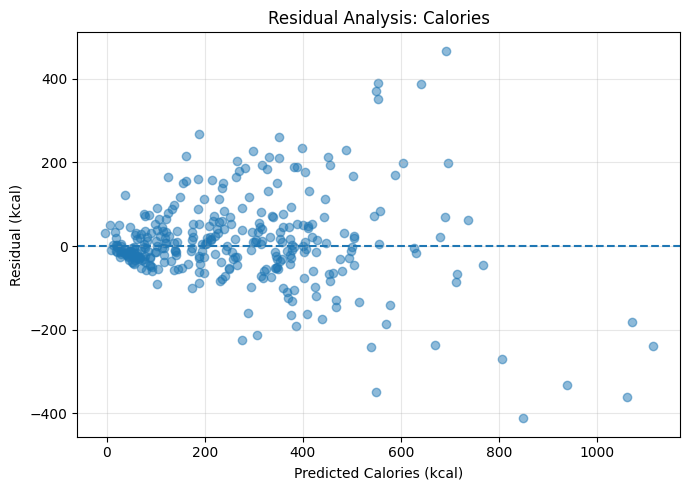

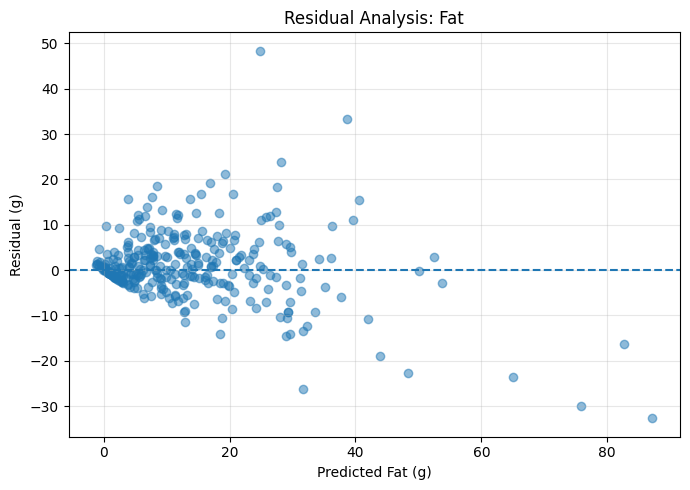

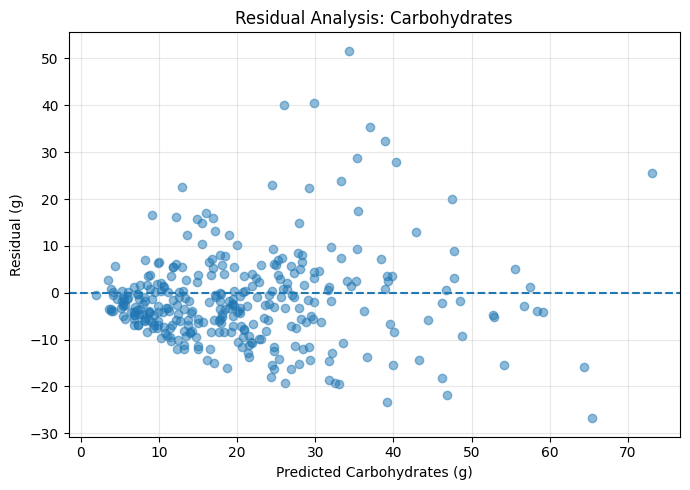

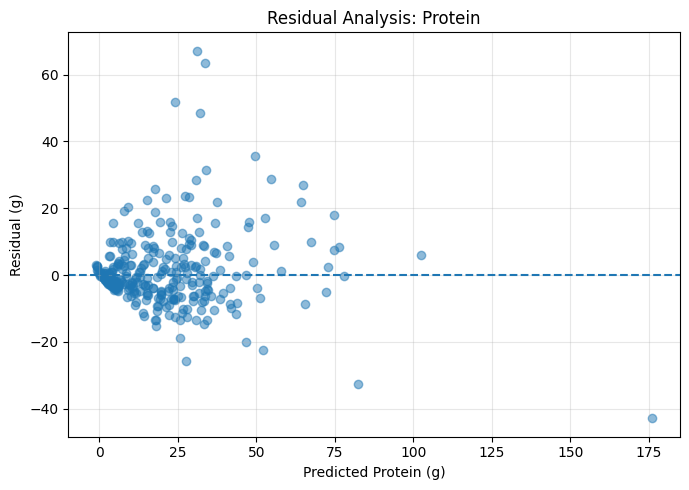

In [48]:
residuals = targets - predictions

for i, (nutrient, unit) in enumerate(zip(nutrient_names, units)):

    plt.figure(figsize=(7, 5))

    plt.scatter(
        predictions[:, i],
        residuals[:, i],
        alpha=0.5
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel(
        f"Predicted {nutrient} ({unit})"
    )

    plt.ylabel(
        f"Residual ({unit})"
    )

    plt.title(
        f"Residual Analysis: {nutrient}"
    )

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    filename = (
        f"/kaggle/working/"
        f"residuals_{nutrient.lower()}.png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [49]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 615.8 kB/s eta 0:00:00 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [50]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [51]:
# Select one test sample
sample_index = 10

sample_row = test_df.iloc[sample_index]

image_path = sample_row["image_path"]

print("Dish ID:", sample_row["dish_id"])
print("Image:", image_path)

print("\nActual nutrients:")
print(
    sample_row[
        ["calories", "fat", "carb", "protein"]
    ]
)

Dish ID: dish_1564170173
Image: /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/imagery/realsense_overhead/dish_1564170173/rgb.png

Actual nutrients:
calories    79.880005
fat             3.677
carb        11.610001
protein         2.095
Name: 10, dtype: object


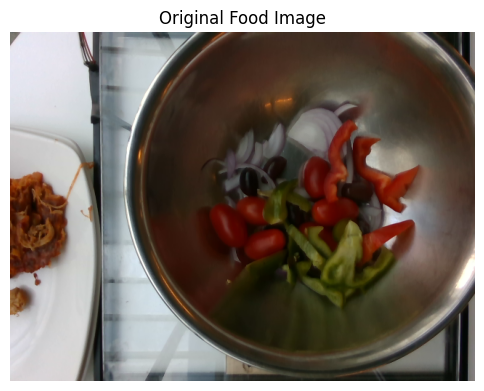

In [52]:
original_image = Image.open(
    image_path
).convert("RGB")

plt.figure(figsize=(6, 5))
plt.imshow(original_image)
plt.axis("off")
plt.title("Original Food Image")
plt.show()

In [53]:
input_tensor = val_test_transform(
    original_image
).unsqueeze(0).to(device)

print("Input tensor:", input_tensor.shape)

Input tensor: torch.Size([1, 3, 224, 224])


In [54]:
# Target convolutional layer
target_layers = [
    model.layer4[-1]
]

print("Grad-CAM target layer:", target_layers[0])

Grad-CAM target layer: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)


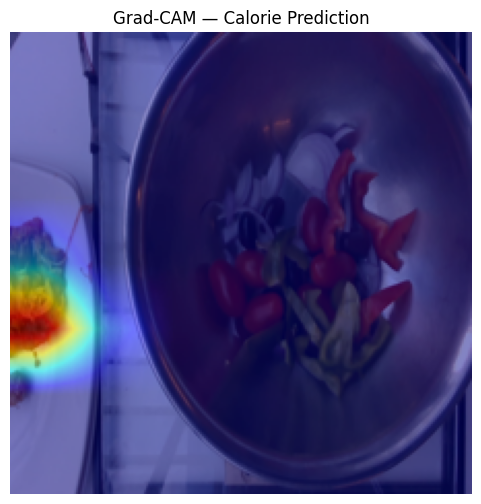

In [55]:
# Put model in evaluation mode
model.eval()

# Create Grad-CAM
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

# Explain the calorie output (index 0)
targets_calories = [
    ClassifierOutputTarget(0)
]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets_calories
)

grayscale_cam = grayscale_cam[0]

# Prepare RGB image for visualization
rgb_image = np.array(
    original_image.resize((224, 224))
).astype(np.float32) / 255.0

visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(7, 6))
plt.imshow(visualization)
plt.axis("off")
plt.title("Grad-CAM — Calorie Prediction")
plt.show()

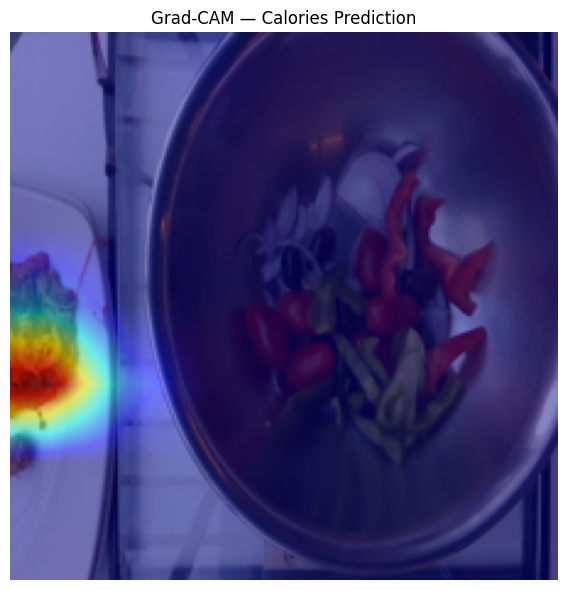

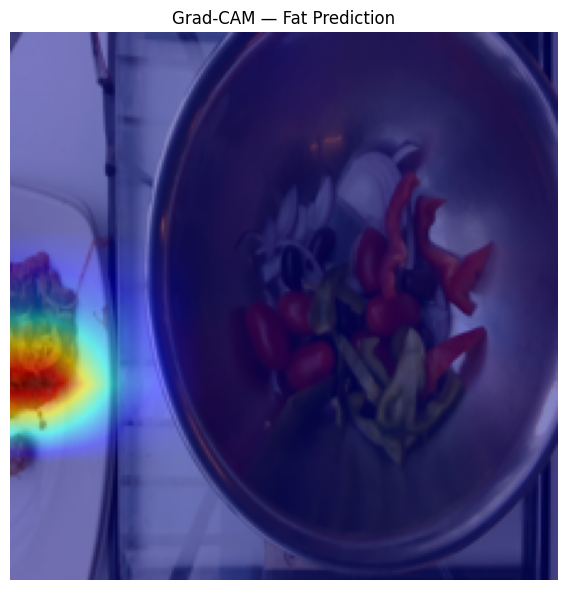

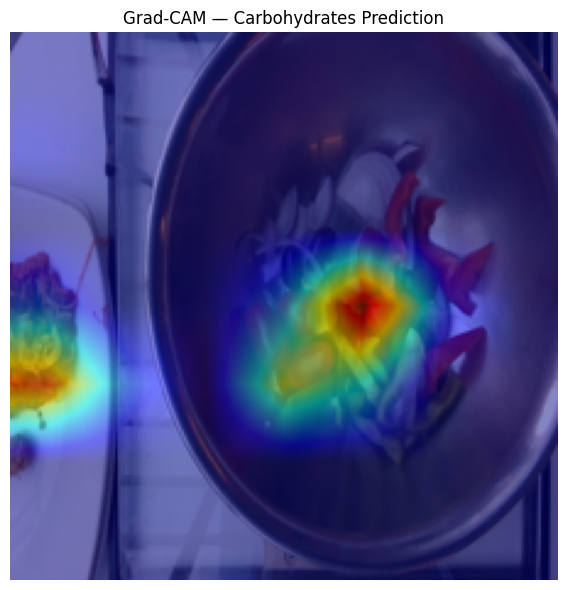

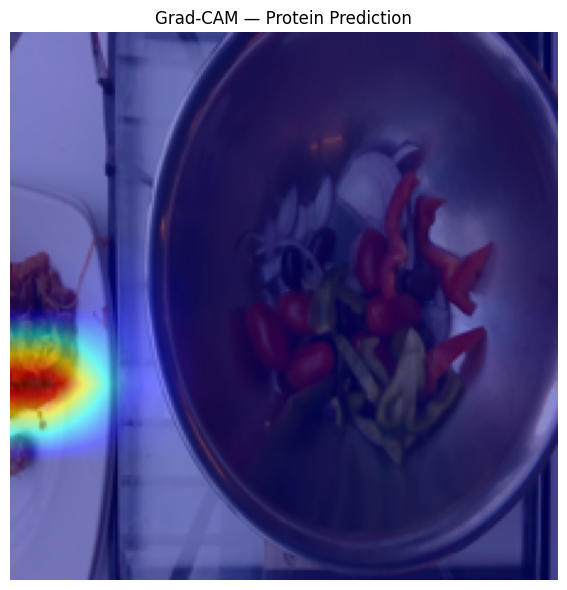

In [56]:
nutrient_names = [
    "Calories",
    "Fat",
    "Carbohydrates",
    "Protein"
]

for nutrient_index, nutrient_name in enumerate(nutrient_names):

    nutrient_targets = [
        ClassifierOutputTarget(nutrient_index)
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=nutrient_targets
    )

    grayscale_cam = grayscale_cam[0]

    visualization = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(7, 6))

    plt.imshow(visualization)

    plt.axis("off")

    plt.title(
        f"Grad-CAM — {nutrient_name} Prediction"
    )

    plt.tight_layout()

    filename = (
        f"/kaggle/working/"
        f"gradcam_{nutrient_name.lower()}.png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [57]:
# --------------------------------------------------
# Create structured nutrition state
# --------------------------------------------------

sample_index = 10

sample_row = test_df.iloc[sample_index]

# CNN prediction for this sample
predicted_nutrients = predictions[sample_index]

# Actual ground-truth nutrients
actual_nutrients = targets[sample_index]

nutrition_state = {
    "dish_id": sample_row["dish_id"],

    "predicted_nutrition": {
        "calories_kcal": float(predicted_nutrients[0]),
        "fat_g": float(predicted_nutrients[1]),
        "carbohydrates_g": float(predicted_nutrients[2]),
        "protein_g": float(predicted_nutrients[3])
    },

    "ground_truth_nutrition": {
        "calories_kcal": float(actual_nutrients[0]),
        "fat_g": float(actual_nutrients[1]),
        "carbohydrates_g": float(actual_nutrients[2]),
        "protein_g": float(actual_nutrients[3])
    }
}

print("Nutrition state:")
print(nutrition_state)

Nutrition state:
{'dish_id': 'dish_1564170173', 'predicted_nutrition': {'calories_kcal': 75.61698913574219, 'fat_g': 2.910861015319824, 'carbohydrates_g': 12.574309349060059, 'protein_g': 2.7566890716552734}, 'ground_truth_nutrition': {'calories_kcal': 79.8800048828125, 'fat_g': 3.677000045776367, 'carbohydrates_g': 11.610000610351562, 'protein_g': 2.0950002670288086}}


In [58]:
import json

def create_nutrition_agent_prompt(
    nutrition_state,
    user_goal="balanced eating"
):

    predicted = nutrition_state["predicted_nutrition"]

    prompt = f"""
You are an AI nutrition decision-support agent.

Your role is to interpret nutritional estimates generated
by a computer vision model from a food image.

The computer vision model estimated:

Calories: {predicted["calories_kcal"]:.2f} kcal
Fat: {predicted["fat_g"]:.2f} g
Carbohydrates: {predicted["carbohydrates_g"]:.2f} g
Protein: {predicted["protein_g"]:.2f} g

User goal:
{user_goal}

Based only on these estimated nutritional values:

1. Summarize the nutritional profile of the meal.
2. Identify notable nutritional characteristics.
3. Explain how the meal may fit the user's stated goal.
4. Suggest practical food-choice adjustments if appropriate.
5. Avoid diagnosing medical conditions.
6. Clearly state that the nutritional values are AI-generated estimates
   rather than laboratory measurements.

Return the response in the following structure:

Nutritional Summary:
...

Interpretation:
...

Decision Support:
...

Suggested Adjustment:
...

Uncertainty:
...
"""

    return prompt


agent_prompt = create_nutrition_agent_prompt(
    nutrition_state,
    user_goal="balanced eating"
)

print(agent_prompt)


You are an AI nutrition decision-support agent.

Your role is to interpret nutritional estimates generated
by a computer vision model from a food image.

The computer vision model estimated:

Calories: 75.62 kcal
Fat: 2.91 g
Carbohydrates: 12.57 g
Protein: 2.76 g

User goal:
balanced eating

Based only on these estimated nutritional values:

1. Summarize the nutritional profile of the meal.
2. Identify notable nutritional characteristics.
3. Explain how the meal may fit the user's stated goal.
4. Suggest practical food-choice adjustments if appropriate.
5. Avoid diagnosing medical conditions.
6. Clearly state that the nutritional values are AI-generated estimates
   rather than laboratory measurements.

Return the response in the following structure:

Nutritional Summary:
...

Interpretation:
...

Decision Support:
...

Suggested Adjustment:
...

Uncertainty:
...



In [59]:
goals = [
    "balanced eating",
    "higher protein intake",
    "lower calorie intake",
    "lower fat intake"
]

for goal in goals:

    prompt = create_nutrition_agent_prompt(
        nutrition_state,
        user_goal=goal
    )

    print("=" * 80)
    print("USER GOAL:", goal)
    print("=" * 80)
    print(prompt)

USER GOAL: balanced eating

You are an AI nutrition decision-support agent.

Your role is to interpret nutritional estimates generated
by a computer vision model from a food image.

The computer vision model estimated:

Calories: 75.62 kcal
Fat: 2.91 g
Carbohydrates: 12.57 g
Protein: 2.76 g

User goal:
balanced eating

Based only on these estimated nutritional values:

1. Summarize the nutritional profile of the meal.
2. Identify notable nutritional characteristics.
3. Explain how the meal may fit the user's stated goal.
4. Suggest practical food-choice adjustments if appropriate.
5. Avoid diagnosing medical conditions.
6. Clearly state that the nutritional values are AI-generated estimates
   rather than laboratory measurements.

Return the response in the following structure:

Nutritional Summary:
...

Interpretation:
...

Decision Support:
...

Suggested Adjustment:
...

Uncertainty:
...

USER GOAL: higher protein intake

You are an AI nutrition decision-support agent.

Your role is

In [60]:
def create_structured_agent_prompt(
    nutrition_state,
    user_goal="balanced eating"
):

    predicted = nutrition_state["predicted_nutrition"]

    return f"""
You are a nutrition decision-support AI agent.

INPUT FROM COMPUTER VISION MODEL:
- Calories: {predicted["calories_kcal"]:.2f} kcal
- Fat: {predicted["fat_g"]:.2f} g
- Carbohydrates: {predicted["carbohydrates_g"]:.2f} g
- Protein: {predicted["protein_g"]:.2f} g

USER GOAL:
{user_goal}

Generate a concise decision-support response.

Return JSON with exactly these fields:

{{
    "nutrition_summary": "...",
    "key_observation": "...",
    "goal_alignment": "...",
    "recommendation": "...",
    "uncertainty_note": "..."
}}

Rules:
- Do not invent nutritional measurements.
- Use the supplied estimates as the nutritional evidence.
- Do not diagnose medical conditions.
- Recommendations should be general dietary decision support.
- Explicitly acknowledge that the nutrient values are AI estimates.
"""

structured_prompt = create_structured_agent_prompt(
    nutrition_state,
    user_goal="balanced eating"
)

print(structured_prompt)


You are a nutrition decision-support AI agent.

INPUT FROM COMPUTER VISION MODEL:
- Calories: 75.62 kcal
- Fat: 2.91 g
- Carbohydrates: 12.57 g
- Protein: 2.76 g

USER GOAL:
balanced eating

Generate a concise decision-support response.

Return JSON with exactly these fields:

{
    "nutrition_summary": "...",
    "key_observation": "...",
    "goal_alignment": "...",
    "recommendation": "...",
    "uncertainty_note": "..."
}

Rules:
- Do not invent nutritional measurements.
- Use the supplied estimates as the nutritional evidence.
- Do not diagnose medical conditions.
- Recommendations should be general dietary decision support.
- Explicitly acknowledge that the nutrient values are AI estimates.



In [61]:
import os

# Check whether common API credentials are already available
api_keys = {
    "OPENAI_API_KEY": os.getenv("OPENAI_API_KEY"),
    "GOOGLE_API_KEY": os.getenv("GOOGLE_API_KEY"),
    "ANTHROPIC_API_KEY": os.getenv("ANTHROPIC_API_KEY")
}

for name, value in api_keys.items():
    print(name, "available:", value is not None)

OPENAI_API_KEY available: False
GOOGLE_API_KEY available: False
ANTHROPIC_API_KEY available: False


In [62]:
# Install/update the OpenAI Python SDK
!pip install -q -U openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 554.7 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 7.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.1/83.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.8/343.8 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 5.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


In [64]:
import os
from kaggle_secrets import UserSecretsClient

# Retrieve the secret securely from Kaggle
user_secrets = UserSecretsClient()

OPENAI_API_KEY = user_secrets.get_secret("OPENAI_API_KEY")

# Make it available to the OpenAI SDK
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

print("✅ OpenAI API key loaded successfully.")
print("Key length:", len(OPENAI_API_KEY))

✅ OpenAI API key loaded successfully.
Key length: 164


In [65]:
from openai import OpenAI

client = OpenAI()

print("✅ OpenAI client initialized.")

✅ OpenAI client initialized.


In [66]:
print(nutrition_state)

{'dish_id': 'dish_1564170173', 'predicted_nutrition': {'calories_kcal': 75.61698913574219, 'fat_g': 2.910861015319824, 'carbohydrates_g': 12.574309349060059, 'protein_g': 2.7566890716552734}, 'ground_truth_nutrition': {'calories_kcal': 79.8800048828125, 'fat_g': 3.677000045776367, 'carbohydrates_g': 11.610000610351562, 'protein_g': 2.0950002670288086}}


In [68]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# Agent evaluation configuration
# --------------------------------------------------

N_SAMPLES = min(50, len(test_df))

user_goals = [
    "balanced eating",
    "higher protein intake",
    "lower calorie intake",
    "lower fat intake"
]

# Select first N test samples
agent_test_df = test_df.iloc[:N_SAMPLES].copy().reset_index(drop=True)

# Corresponding CNN predictions
agent_predictions = predictions[:N_SAMPLES]

# --------------------------------------------------
# Create evaluation cases
# --------------------------------------------------

agent_cases = []

for i in range(N_SAMPLES):

    row = agent_test_df.iloc[i]
    pred = agent_predictions[i]

    for goal in user_goals:

        case = {
            "case_id": f"case_{i+1:03d}_{goal.replace(' ', '_')}",
            "dish_id": row["dish_id"],
            "image_path": row["image_path"],

            "predicted_calories": float(pred[0]),
            "predicted_fat": float(pred[1]),
            "predicted_carb": float(pred[2]),
            "predicted_protein": float(pred[3]),

            "user_goal": goal,

            # Empty fields for actual LLM evaluation
            "agent_response": "",
            "nutrition_consistency": np.nan,
            "goal_alignment": np.nan,
            "actionability": np.nan,
            "uncertainty_awareness": np.nan
        }

        agent_cases.append(case)


agent_cases_df = pd.DataFrame(agent_cases)

print("Number of evaluation cases:", len(agent_cases_df))

display(agent_cases_df.head(10))

Number of evaluation cases: 200


,case_id,dish_id,image_path,predicted_calories,predicted_fat,predicted_carb,predicted_protein,user_goal,agent_response,nutrition_consistency,goal_alignment,actionability,uncertainty_awareness
0,case_001_balanced_eating,dish_1560357297,/kaggle/input/datasets/gillesokhin/nutrition5k...,553.268311,38.641937,26.902733,30.881733,balanced eating,,NaN,NaN,NaN,NaN
1,case_001_higher_protein_intake,dish_1560357297,/kaggle/input/datasets/gillesokhin/nutrition5k...,553.268311,38.641937,26.902733,30.881733,higher protein intake,,NaN,NaN,NaN,NaN
2,case_001_lower_calorie_intake,dish_1560357297,/kaggle/input/datasets/gillesokhin/nutrition5k...,553.268311,38.641937,26.902733,30.881733,lower calorie intake,,NaN,NaN,NaN,NaN
3,case_001_lower_fat_intake,dish_1560357297,/kaggle/input/datasets/gillesokhin/nutrition5k...,553.268311,38.641937,26.902733,30.881733,lower fat intake,,NaN,NaN,NaN,NaN
4,case_002_balanced_eating,dish_1563304261,/kaggle/input/datasets/gillesokhin/nutrition5k...,51.089935,2.588883,5.654192,1.667313,balanced eating,,NaN,NaN,NaN,NaN
5,case_002_higher_protein_intake,dish_1563304261,/kaggle/input/datasets/gillesokhin/nutrition5k...,51.089935,2.588883,5.654192,1.667313,higher protein intake,,NaN,NaN,NaN,NaN
6,case_002_lower_calorie_intake,dish_1563304261,/kaggle/input/datasets/gillesokhin/nutrition5k...,51.089935,2.588883,5.654192,1.667313,lower calorie intake,,NaN,NaN,NaN,NaN
7,case_002_lower_fat_intake,dish_1563304261,/kaggle/input/datasets/gillesokhin/nutrition5k...,51.089935,2.588883,5.654192,1.667313,lower fat intake,,NaN,NaN,NaN,NaN
8,case_003_balanced_eating,dish_1562704665,/kaggle/input/datasets/gillesokhin/nutrition5k...,237.293976,5.375197,25.185564,21.305229,balanced eating,,NaN,NaN,NaN,NaN
9,case_003_higher_protein_intake,dish_1562704665,/kaggle/input/datasets/gillesokhin/nutrition5k...,237.293976,5.375197,25.185564,21.305229,higher protein intake,,NaN,NaN,NaN,NaN


In [69]:
def build_agent_prompt_from_row(row):

    return f"""
You are a Generative AI nutrition decision-support agent.

A computer vision model analyzed a food image and estimated:

Calories: {row["predicted_calories"]:.2f} kcal
Fat: {row["predicted_fat"]:.2f} g
Carbohydrates: {row["predicted_carb"]:.2f} g
Protein: {row["predicted_protein"]:.2f} g

The user's goal is:

{row["user_goal"]}

Provide decision-support guidance based on these estimated
nutritional values.

Your response should:

1. Summarize the estimated nutritional profile.
2. Identify the most relevant characteristic for the user's goal.
3. Explain whether the meal appears aligned with the goal.
4. Provide one or two practical food-choice adjustments.
5. Clearly acknowledge that the values are AI estimates
   derived from a food image and may contain error.
6. Do not diagnose medical conditions.
7. Do not claim that the estimates are laboratory measurements.

Return:

Nutritional Summary:
...

Goal Alignment:
...

Decision Support:
...

Suggested Adjustment:
...

Uncertainty:
...
"""


agent_cases_df["agent_prompt"] = agent_cases_df.apply(
    build_agent_prompt_from_row,
    axis=1
)

print(agent_cases_df.loc[0, "agent_prompt"])


You are a Generative AI nutrition decision-support agent.

A computer vision model analyzed a food image and estimated:

Calories: 553.27 kcal
Fat: 38.64 g
Carbohydrates: 26.90 g
Protein: 30.88 g

The user's goal is:

balanced eating

Provide decision-support guidance based on these estimated
nutritional values.

Your response should:

1. Summarize the estimated nutritional profile.
2. Identify the most relevant characteristic for the user's goal.
3. Explain whether the meal appears aligned with the goal.
4. Provide one or two practical food-choice adjustments.
5. Clearly acknowledge that the values are AI estimates
   derived from a food image and may contain error.
6. Do not diagnose medical conditions.
7. Do not claim that the estimates are laboratory measurements.

Return:

Nutritional Summary:
...

Goal Alignment:
...

Decision Support:
...

Suggested Adjustment:
...

Uncertainty:
...



In [70]:
AGENT_DATASET_PATH = (
    "/kaggle/working/"
    "nutrition5k_agent_evaluation_cases.csv"
)

agent_cases_df.to_csv(
    AGENT_DATASET_PATH,
    index=False
)

print("Saved:")
print(AGENT_DATASET_PATH)

Saved:
/kaggle/working/nutrition5k_agent_evaluation_cases.csv


In [71]:
evaluation_rubric = {
    "nutrition_consistency": {
        1: "Major contradiction or incorrect interpretation of nutrient estimates",
        2: "Several inconsistencies",
        3: "Mostly consistent with minor issues",
        4: "Consistent with the supplied estimates",
        5: "Highly precise and consistently grounded in the supplied estimates"
    },

    "goal_alignment": {
        1: "Does not address the user's goal",
        2: "Weak connection to the goal",
        3: "Partially addresses the goal",
        4: "Clearly addresses the goal",
        5: "Strongly and specifically addresses the goal"
    },

    "actionability": {
        1: "No useful recommendation",
        2: "Very vague recommendation",
        3: "Moderately useful recommendation",
        4: "Clear practical recommendation",
        5: "Highly practical and specific decision support"
    },

    "uncertainty_awareness": {
        1: "Presents estimates as certain facts",
        2: "Minimal acknowledgement of uncertainty",
        3: "Acknowledges uncertainty generally",
        4: "Clearly identifies image-based estimation uncertainty",
        5: "Explicitly and appropriately communicates uncertainty and limitations"
    }
}

print("Evaluation rubric created.")

Evaluation rubric created.


In [72]:
# --------------------------------------------------
# Final performance table
# --------------------------------------------------

final_metrics = metrics_df.copy()

final_metrics["MAE"] = final_metrics["MAE"].round(3)
final_metrics["RMSE"] = final_metrics["RMSE"].round(3)
final_metrics["R2"] = final_metrics["R2"].round(3)

display(final_metrics)

,Nutrient,MAE,RMSE,R2
0,calories,70.977,107.732,0.748
1,fat,5.054,7.822,0.662
2,carb,7.179,10.005,0.638
3,protein,6.975,11.195,0.750


In [73]:
overall_mae = metrics_df["MAE"].mean()
overall_rmse = metrics_df["RMSE"].mean()
overall_r2 = metrics_df["R2"].mean()

print(f"Overall Mean MAE:  {overall_mae:.3f}")
print(f"Overall Mean RMSE: {overall_rmse:.3f}")
print(f"Overall Mean R²:   {overall_r2:.3f}")

Overall Mean MAE:  22.546
Overall Mean RMSE: 34.188
Overall Mean R²:   0.700


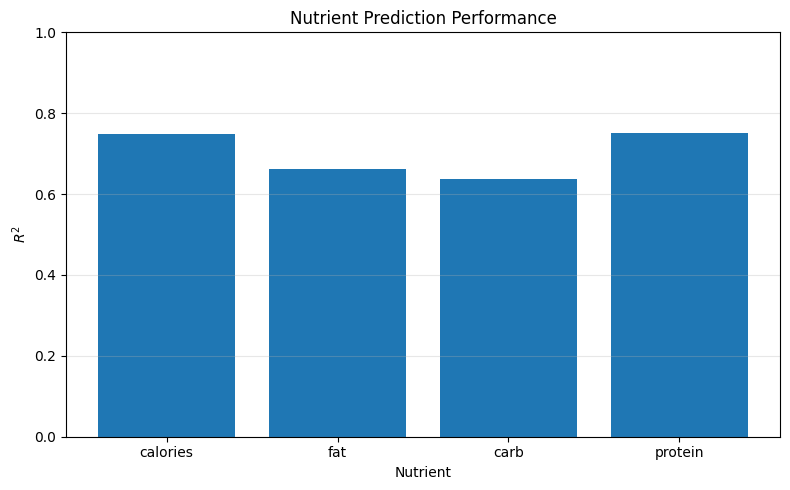

In [74]:
import matplotlib.pyplot as plt

nutrients = metrics_df["Nutrient"].tolist()
r2_values = metrics_df["R2"].values

plt.figure(figsize=(8, 5))

plt.bar(
    nutrients,
    r2_values
)

plt.ylabel("$R^2$")
plt.xlabel("Nutrient")
plt.title("Nutrient Prediction Performance")

plt.ylim(0, 1)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/nutrient_r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

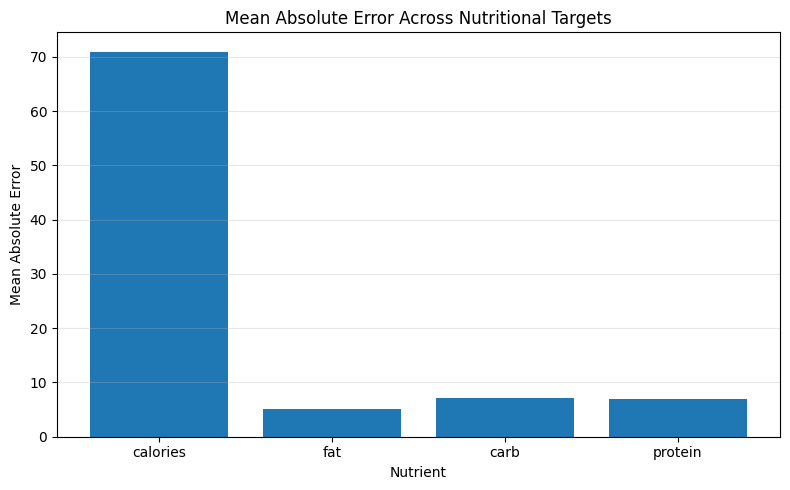

In [75]:
mae_values = metrics_df["MAE"].values

plt.figure(figsize=(8, 5))

plt.bar(
    nutrients,
    mae_values
)

plt.ylabel("Mean Absolute Error")
plt.xlabel("Nutrient")
plt.title("Mean Absolute Error Across Nutritional Targets")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/nutrient_mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
percentage_errors = (
    np.abs(targets - predictions)
    / np.maximum(np.abs(targets), 1e-6)
) * 100

percentage_error_df = pd.DataFrame({
    "Nutrient": nutrient_names,
    "Mean Percentage Error (%)": percentage_errors.mean(axis=0),
    "Median Percentage Error (%)": np.median(
        percentage_errors,
        axis=0
    )
})

display(
    percentage_error_df.round(2)
)

,Nutrient,Mean Percentage Error (%),Median Percentage Error (%)
0,Calories,4.766000e+01,23.719999
1,Fat,1.918200e+02,38.840000
2,Carbohydrates,3.278102e+06,35.560001
3,Protein,9.845000e+01,39.830002


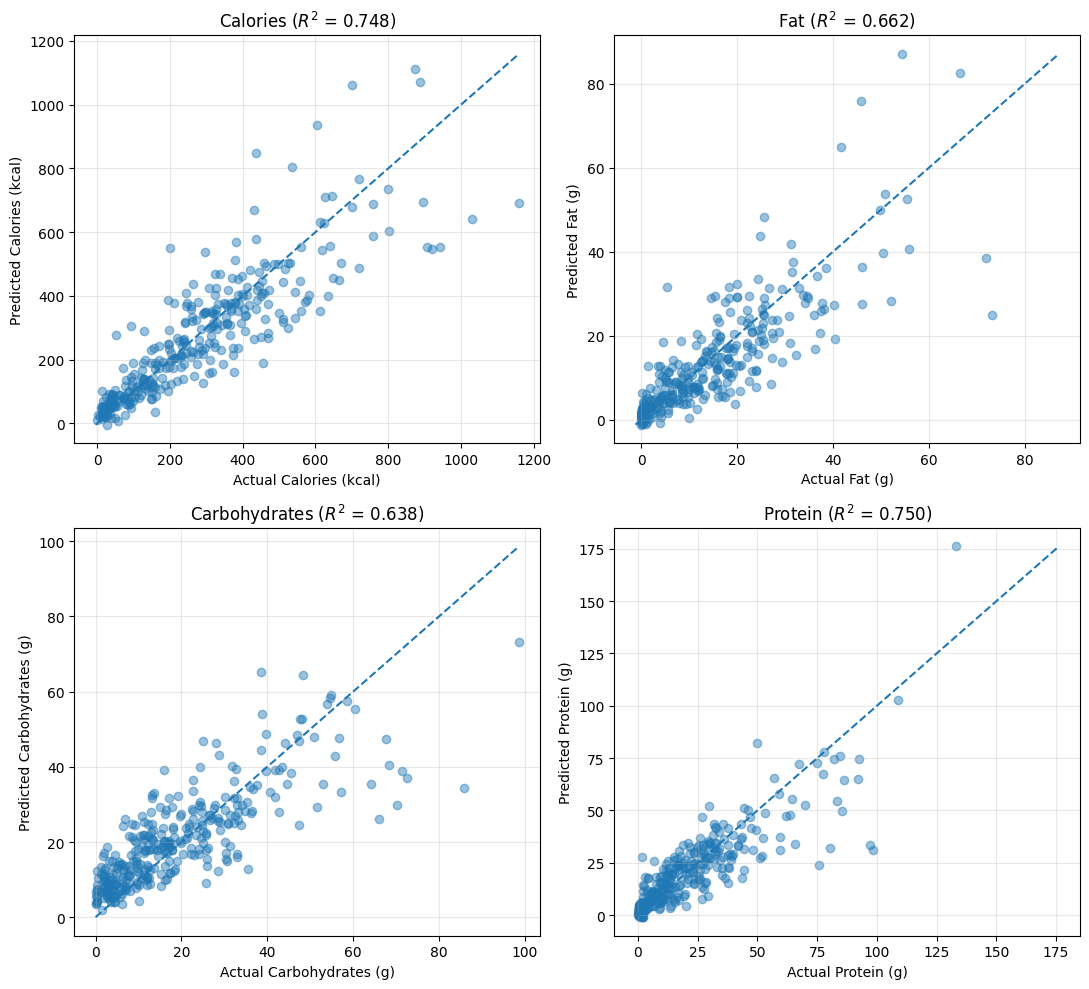

In [77]:
import matplotlib.pyplot as plt

nutrient_names = [
    "Calories",
    "Fat",
    "Carbohydrates",
    "Protein"
]

units = [
    "kcal",
    "g",
    "g",
    "g"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 10)
)

for i, ax in enumerate(axes.flat):

    ax.scatter(
        targets[:, i],
        predictions[:, i],
        alpha=0.45
    )

    # Perfect prediction line
    min_value = min(
        targets[:, i].min(),
        predictions[:, i].min()
    )

    max_value = max(
        targets[:, i].max(),
        predictions[:, i].max()
    )

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    ax.set_xlabel(
        f"Actual {nutrient_names[i]} ({units[i]})"
    )

    ax.set_ylabel(
        f"Predicted {nutrient_names[i]} ({units[i]})"
    )

    ax.set_title(
        f"{nutrient_names[i]} "
        f"($R^2$ = {metrics_df.loc[i, 'R2']:.3f})"
    )

    ax.grid(
        True,
        alpha=0.3
    )

plt.tight_layout()

plt.savefig(
    "/kaggle/working/combined_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()